# Feature-Based Structural Damage Detection (FSDD)
## Part 1: Feature Extraction and Preprocessing

This notebook implements the feature extraction pipeline described in the FSDD thesis:
- OpenCV-based image preprocessing
- ISBDA dataset loading with 5-class damage structure
- FSDD `detect_feature()` algorithm (patch brightness filtering)
- ORB/SIFT `detectAndCompute` feature extraction loop
- Harris corner detection with Sobel gradients
- Contour, vertex, and surface quality extraction
- Bounding box overlay visualisation

**Authors:** F. Joevita Faustina Doss, R. Sasana, P. Rakshitha  
**Institution:** Anna University, MIT Campus – Department of Computer Technology

## 1. Install Dependencies

In [ ]:
# Run this cell once to install all required packages (Google Colab / local)
!pip install opencv-python-headless scikit-image scipy numpy matplotlib ultralytics roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 91.1 MB/s eta 0:00:00


## 2. Imports

In [ ]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import signal as sig
from scipy import ndimage as ndi
from skimage.io import imread
from skimage.color import rgb2gray

# Colab GPU check
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


## 3. Dataset Configuration

The FSDD system uses the **ISBDA dataset** (~160 UAV aerial images with 5 damage classes).

Insert your Roboflow API key below or point `DATASET_DIR` to your local dataset folder.

In [ ]:
# ---- Damage class definitions (thesis Chapter 3) ----
DAMAGE_CLASSES = {
    0: "no_d",      # No damage
    1: "slight",    # Slight damage
    2: "slight_h",  # Slight damage – high confidence
    3: "severe",    # Severe damage
    4: "severe_h"   # Severe damage – high confidence
}
NUM_CLASSES = len(DAMAGE_CLASSES)

# ---- Dataset directory ----
USE_ROBOFLOW       = True
ROBOFLOW_API_KEY   = "VyiTP0iWE0793IW6xR5a"
ROBOFLOW_WORKSPACE = "loucif-hebbache"
ROBOFLOW_PROJECT   = "isbda"
ROBOFLOW_VERSION   = 1

DATASET_DIR  = "./dataset"
TRAIN_SPLIT  = 0.70
TEST_SPLIT   = 0.30

print("Damage classes:", DAMAGE_CLASSES)


Damage classes: {0: 'no_d', 1: 'slight', 2: 'slight_h', 3: 'severe', 4: 'severe_h'}


In [ ]:
# ---- Roboflow dataset download ----
from roboflow import Roboflow
rf      = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
version = project.version(ROBOFLOW_VERSION)
dataset = version.download("yolov8")
DATASET_DIR = dataset.location
print(f"Dataset downloaded to: {DATASET_DIR}")
import os
os.makedirs(f"{DATASET_DIR}/images", exist_ok=True)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ISBDA-1 in yolov8:: 100%|██████████| 9965/9965 [00:01<00:00, 5777.24it/s] 


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset downloaded to: /content/ISBDA-1


## 4. OpenCV Preprocessing Pipeline

As described in thesis Chapter 3.1.2: images are resized, contrast-enhanced, and normalised before feature extraction.

Downloaded demo image.
Loaded:  dataset/images/demo_image.jpg
Shape:   (640, 640, 3)


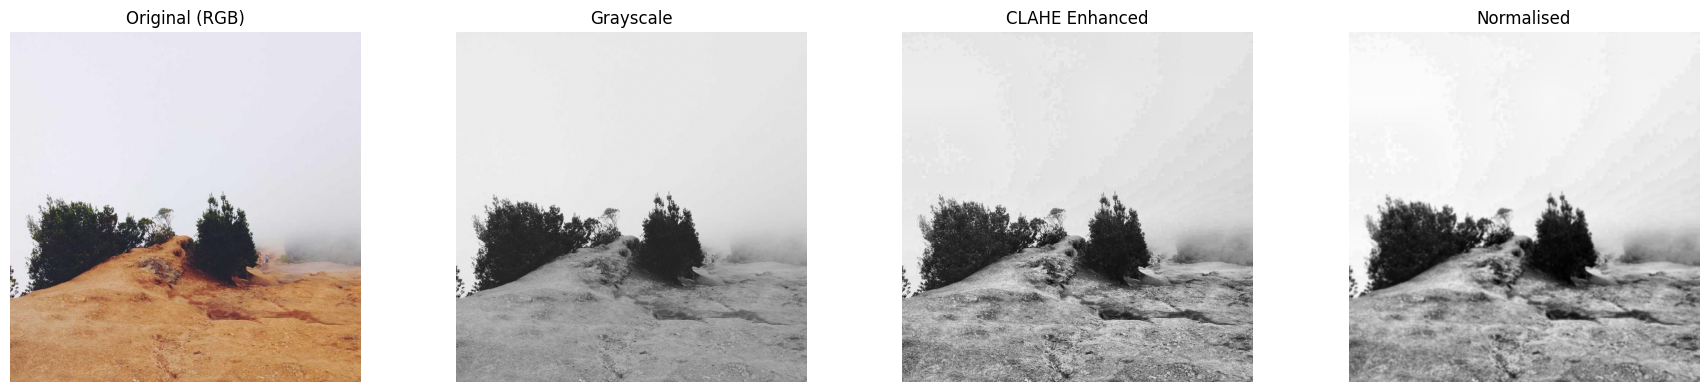

In [ ]:
import os
import glob
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt


def preprocess_image(image_path: str, target_size: tuple = (640, 640)) -> dict:
    """
    OpenCV preprocessing pipeline (thesis Chapter 3.1.2).

    Steps:
        1. Load image via OpenCV (BGR -> RGB)
        2. Resize to target_size
        3. CLAHE contrast enhancement
        4. Gaussian blur (noise reduction)
        5. Normalise to [0, 1]

    Returns a dict with 'original', 'rgb', 'gray', 'enhanced', 'normalised'.
    """
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot load image: {image_path}")

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_res  = cv2.resize(img_rgb, target_size, interpolation=cv2.INTER_LINEAR)
    img_gray = cv2.cvtColor(img_res, cv2.COLOR_RGB2GRAY)

    # CLAHE contrast enhancement
    clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_gray)

    # Gaussian blur to reduce sensor noise
    img_blur  = cv2.GaussianBlur(img_clahe, (5, 5), 0)

    # Normalise
    img_norm  = img_blur.astype(np.float32) / 255.0

    return {
        "original"  : img_bgr,
        "rgb"       : img_res,
        "gray"      : img_gray,
        "enhanced"  : img_clahe,
        "normalised": img_norm,
    }


# ----- Demo: use sample image or any image in dataset/images/ -----
sample_paths = glob.glob("dataset/images/*.jpg") + glob.glob("dataset/images/*.png")

if not sample_paths:
    os.makedirs("dataset/images", exist_ok=True)
    url         = "https://picsum.photos/640/640.jpg"
    sample_path = "dataset/images/demo_image.jpg"

    print("Downloading demo image...")
    response = requests.get(url, headers={"User-Agent": "ThesisNotebook/1.0"}, timeout=10)
    response.raise_for_status()
    with open(sample_path, "wb") as f:
        f.write(response.content)

    sample_paths = [sample_path]
    print("Downloaded demo image.")

processed = preprocess_image(sample_paths[0])
print(f"Loaded:  {sample_paths[0]}")
print(f"Shape:   {processed['rgb'].shape}")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
titles = ["Original (RGB)", "Grayscale", "CLAHE Enhanced", "Normalised"]
imgs   = [processed["rgb"], processed["gray"], processed["enhanced"], processed["normalised"]]
cmaps  = [None, "gray", "gray", "gray"]
for ax, img, title, cmap in zip(axes, imgs, titles, cmaps):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig("preprocessing_pipeline.png", dpi=150)
plt.show()

## 5. FSDD Feature Extraction Algorithm

Implements the algorithm specified in thesis **Chapter 3.3** exactly:
- `detect_feature(I, x, y, s, angle)` – patch brightness filter
- `detectAndCompute` via ORB to get feature points and descriptors
- Filter loop appending only features that pass brightness check

In [ ]:
# ---------- Thesis Algorithm 3.3 – FSDD Feature Extraction ----------

PATCH_SIZE        = 20      # Thesis algorithm default
BRIGHTNESS_THRESH = 150     # Thesis: return True (damage candidate) if avg < 150


def detect_feature(I: np.ndarray, x: float, y: float,
                   s: float, angle: float,
                   patch_size: int = PATCH_SIZE,
                   threshold: int  = BRIGHTNESS_THRESH) -> bool:
    """
    FSDD damage-candidate filter (thesis Chapter 3.3).

    Extracts a patch of size (patch_size x patch_size) centred at (x, y)
    from grayscale image I.  Returns True if the mean brightness of the
    patch is below the threshold (indicating a potentially dark, damaged
    region).
    """
    h, w  = I.shape[:2]
    half  = patch_size // 2
    y1    = max(0, int(y - half))
    y2    = min(h, int(y + half))
    x1    = max(0, int(x - half))
    x2    = min(w, int(x + half))
    patch = I[y1:y2, x1:x2]
    if patch.size == 0:
        return False
    average_brightness = patch.mean()
    return average_brightness < threshold


def fsdd_extract_features(gray_image: np.ndarray,
                          n_features: int = 1000) -> tuple:
    """
    Full FSDD feature extraction loop (thesis Chapter 3.3).

    1. Runs ORB detectAndCompute on the grayscale image.
    2. Filters keypoints using detect_feature() (brightness check).
    3. Returns filtered (keypoints, descriptors).
    """
    # Use uint8 image for OpenCV
    if gray_image.dtype != np.uint8:
        gray_u8 = (gray_image * 255).astype(np.uint8)
    else:
        gray_u8 = gray_image

    orb = cv2.ORB_create(nfeatures=n_features)
    feature_points_list, feature_descriptors_list = orb.detectAndCompute(gray_u8, None)

    if feature_points_list is None or len(feature_points_list) == 0:
        return [], None

    features_list      = []
    kept_keypoints     = []

    for kp, desc in zip(feature_points_list, feature_descriptors_list):
        x_coord, y_coord = kp.pt
        scale            = kp.size
        orientation      = kp.angle
        if detect_feature(gray_u8, x_coord, y_coord, scale, orientation):
            features_list.append(desc)
            kept_keypoints.append(kp)

    descriptors = np.array(features_list, dtype=np.uint8) if features_list else None
    return kept_keypoints, descriptors


# ----- Run on sample image -----
gray_u8   = processed["enhanced"]
kps, descs = fsdd_extract_features(gray_u8)

print(f"Total ORB keypoints detected : {len(cv2.ORB_create(1000).detect(gray_u8))}")
print(f"Keypoints AFTER brightness filter (detect_feature): {len(kps)}")
if descs is not None:
    print(f"Descriptor shape : {descs.shape}")

Total ORB keypoints detected : 1000
Keypoints AFTER brightness filter (detect_feature): 672
Descriptor shape : (672, 32)


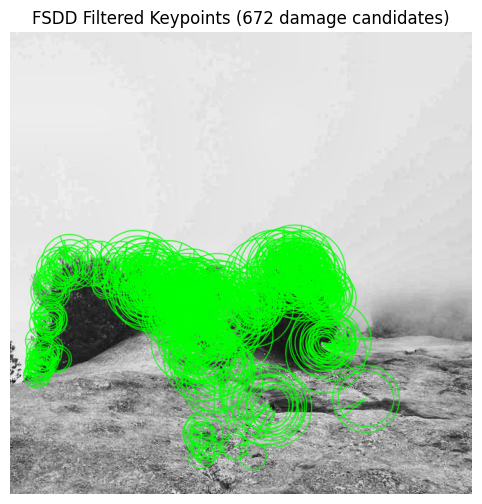

In [ ]:
# Visualise filtered keypoints on the image
kp_img = cv2.drawKeypoints(
    gray_u8, kps, None,
    color=(0, 255, 0),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(kp_img, cv2.COLOR_BGR2RGB))
plt.title(f"FSDD Filtered Keypoints ({len(kps)} damage candidates)")
plt.axis("off")
plt.savefig("fsdd_keypoints.png", dpi=150)
plt.show()

## 6. Harris Corner Detection with Sobel Gradients

Gradient-based feature extraction as described in thesis Chapter 3.1.1.

Detected corners : 232,972  pixels
Detected edges   : 127,761  pixels


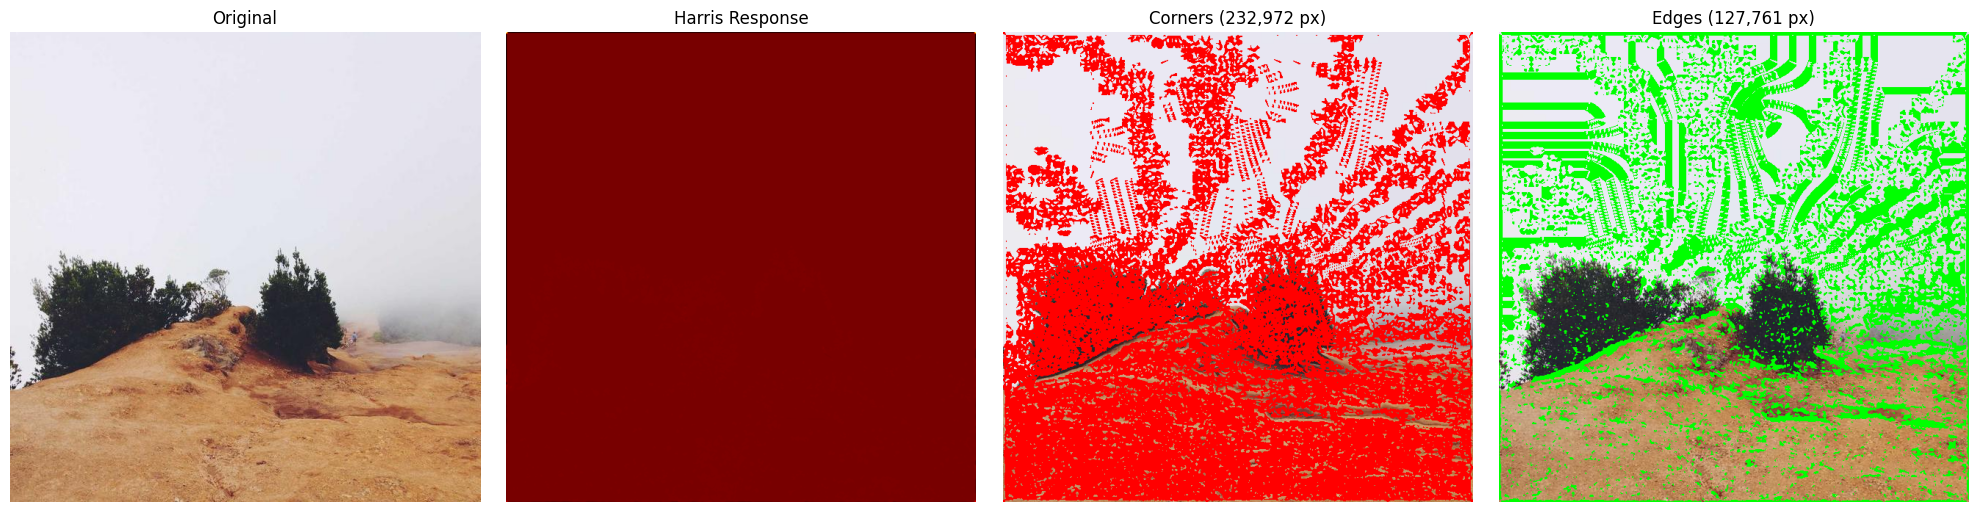

In [ ]:
def compute_sobel_gradients(gray_float: np.ndarray) -> tuple:
    """Compute X and Y gradients using Sobel kernels."""
    kernel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    kernel_y = np.array([[ 1, 2, 1], [ 0, 0, 0], [-1,-2,-1]])
    I_x = sig.convolve2d(gray_float, kernel_x, mode="same")
    I_y = sig.convolve2d(gray_float, kernel_y, mode="same")
    return I_x, I_y


def compute_harris_response(gray_float: np.ndarray,
                            sigma: float = 1.0,
                            k: float     = 0.05) -> np.ndarray:
    """
    Harris corner response map.
    R = det(A) - k * trace(A)^2
    """
    I_x, I_y = compute_sobel_gradients(gray_float)
    Ixx = ndi.gaussian_filter(I_x ** 2,  sigma=sigma)
    Iyy = ndi.gaussian_filter(I_y ** 2,  sigma=sigma)
    Ixy = ndi.gaussian_filter(I_x * I_y, sigma=sigma)
    detA   = Ixx * Iyy - Ixy ** 2
    traceA = Ixx + Iyy
    return detA - k * (traceA ** 2), I_x, I_y


def label_corners_edges(harris_response: np.ndarray,
                        rgb_image: np.ndarray) -> tuple:
    """
    Vectorised corner/edge labeling (no slow Python loops).
    Returns colour-coded corner and edge overlay images.
    """
    corner_img = rgb_image.copy()
    edge_img   = rgb_image.copy()
    corner_mask = harris_response > 0
    edge_mask   = harris_response < 0
    corner_img[corner_mask] = [255, 0,   0]   # Red  = corners
    edge_img[edge_mask]     = [0,   255, 0]   # Green = edges
    return corner_img, edge_img, corner_mask, edge_mask


# Compute on sample
gray_float   = processed["normalised"]
harris, I_x, I_y = compute_harris_response(gray_float, sigma=1.0, k=0.05)
corner_img, edge_img, c_mask, e_mask = label_corners_edges(harris, processed["rgb"])

n_corners = int(c_mask.sum())
n_edges   = int(e_mask.sum())
print(f"Detected corners : {n_corners:,}  pixels")
print(f"Detected edges   : {n_edges:,}  pixels")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(processed["rgb"]); axes[0].set_title("Original")
axes[1].imshow(harris, cmap="hot"); axes[1].set_title("Harris Response")
axes[2].imshow(corner_img); axes[2].set_title(f"Corners ({n_corners:,} px)")
axes[3].imshow(edge_img);   axes[3].set_title(f"Edges ({n_edges:,} px)")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.savefig("harris_detection.png", dpi=150)
plt.show()

## 7. Contour and Vertex Extraction

Implements contour detection and vertex approximation as listed in the FSDD algorithm output specification (thesis Chapter 3.3).

Contours detected   : 1841
Total vertices      : 11066
Avg surface quality : 132.90


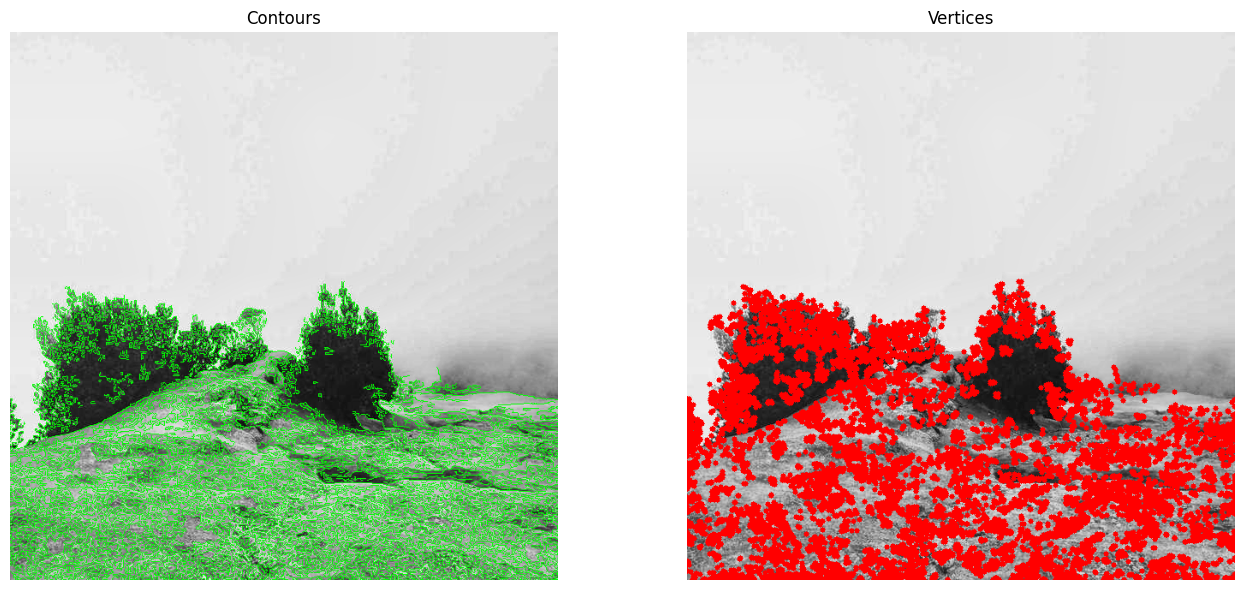

In [ ]:
def extract_contours_and_vertices(gray_u8: np.ndarray,
                                  canny_low: int  = 50,
                                  canny_high: int = 150,
                                  epsilon_ratio: float = 0.02) -> dict:
    """
    Extract contours, vertices (polygon approximation), and surface quality
    metrics from a grayscale image (thesis Chapter 3.3 output spec).

    Returns:
        dict with keys: 'contours', 'vertices', 'surface_quality',
                        'contour_image', 'vertex_image'
    """
    edges    = cv2.Canny(gray_u8, canny_low, canny_high)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    all_vertices      = []
    surface_qualities = []

    contour_img = cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2BGR)
    vertex_img  = contour_img.copy()

    for cnt in contours:
        # Draw contour
        cv2.drawContours(contour_img, [cnt], -1, (0, 255, 0), 1)

        # Vertex approximation
        epsilon  = epsilon_ratio * cv2.arcLength(cnt, True)
        approx   = cv2.approxPolyDP(cnt, epsilon, True)
        all_vertices.append(approx)

        # Draw vertices
        for pt in approx:
            cv2.circle(vertex_img, tuple(pt[0]), 3, (0, 0, 255), -1)

        # Surface quality = mean pixel intensity inside bounding rect
        x, y, w, h = cv2.boundingRect(cnt)
        roi        = gray_u8[y:y+h, x:x+w]
        sq         = float(roi.mean()) if roi.size > 0 else 0.0
        surface_qualities.append(sq)

    return {
        "contours"        : contours,
        "vertices"        : all_vertices,
        "surface_quality" : surface_qualities,
        "contour_image"   : cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB),
        "vertex_image"    : cv2.cvtColor(vertex_img,  cv2.COLOR_BGR2RGB)
    }


result = extract_contours_and_vertices(gray_u8)
print(f"Contours detected   : {len(result['contours'])}")
print(f"Total vertices      : {sum(len(v) for v in result['vertices'])}")
print(f"Avg surface quality : {np.mean(result['surface_quality']):.2f}" if result['surface_quality'] else "N/A")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(result["contour_image"]); axes[0].set_title("Contours")
axes[1].imshow(result["vertex_image"]);  axes[1].set_title("Vertices")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.savefig("contours_vertices.png", dpi=150)
plt.show()

## 8. Bounding Box Overlay Visualisation

Draws predicted damage bounding boxes on the input image.

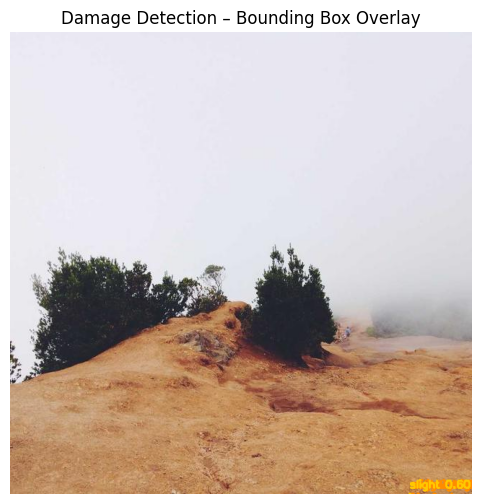

In [ ]:
def draw_damage_boxes(rgb_image: np.ndarray, boxes: list,
                      class_ids: list, confidences: list,
                      class_names: dict = DAMAGE_CLASSES,
                      color_map: dict = None) -> np.ndarray:
    """
    Draw bounding boxes with class labels on an RGB image.

    Args:
        boxes:       list of (x, y, w, h) in pixel coordinates
        class_ids:   list of integer class indices
        confidences: list of float confidence scores
    """
    if color_map is None:
        color_map = {
            0: (0, 200, 0),     # no_d      – green
            1: (255, 200, 0),   # slight    – yellow
            2: (255, 140, 0),   # slight_h  – orange
            3: (255, 50,  0),   # severe    – red-orange
            4: (200, 0,   0)    # severe_h  – red
        }
    out = rgb_image.copy()
    for (x, y, w, h), cls_id, conf in zip(boxes, class_ids, confidences):
        color = color_map.get(cls_id, (128, 128, 128))
        cv2.rectangle(out, (x, y), (x + w, y + h), color, 2)
        label = f"{class_names[cls_id]} {conf:.2f}"
        cv2.putText(out, label, (x, max(y - 8, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return out


# --- Demo: generate mock boxes from contours ---
demo_boxes, demo_cls, demo_conf = [], [], []
for i, cnt in enumerate(result["contours"][:5]):
    x, y, w, h = cv2.boundingRect(cnt)
    sq          = result["surface_quality"][i]
    cls_id      = min(int(sq / 60), 4)   # map brightness to class
    demo_boxes.append((x, y, w, h))
    demo_cls.append(cls_id)
    demo_conf.append(round(max(0.5, 1.0 - sq / 255.0), 2))

annotated = draw_damage_boxes(processed["rgb"], demo_boxes, demo_cls, demo_conf)
plt.figure(figsize=(10, 6))
plt.imshow(annotated)
plt.title("Damage Detection – Bounding Box Overlay")
plt.axis("off")
plt.savefig("bounding_box_overlay.png", dpi=150)
plt.show()

## 9. Batch Feature Extraction Pipeline

Runs the complete feature extraction on all images in the dataset and saves a summary.

In [ ]:
def process_dataset(image_dir: str, max_images: int = None) -> list:
    """
    Runs the full FSDD feature extraction pipeline on every image in image_dir.
    Returns a list of dicts with per-image features.
    """
    paths   = glob.glob(os.path.join(image_dir, "*.jpg")) + \
              glob.glob(os.path.join(image_dir, "*.png"))
    if max_images:
        paths = paths[:max_images]

    records = []
    for i, path in enumerate(paths):
        try:
            proc   = preprocess_image(path)
            gray   = proc["enhanced"]
            kps, descs = fsdd_extract_features(gray)
            harris, _, _ = compute_harris_response(proc["normalised"])
            n_corners = int((harris > 0).sum())
            ctr       = extract_contours_and_vertices(gray)
            records.append({
                "path"           : path,
                "n_keypoints"    : len(kps),
                "descriptor_dim" : descs.shape[1] if descs is not None else 0,
                "n_corners"      : n_corners,
                "n_contours"     : len(ctr["contours"]),
                "avg_surface_q"  : float(np.mean(ctr["surface_quality"])) if ctr["surface_quality"] else 0.0
            })
            if (i + 1) % 10 == 0:
                print(f"Processed {i+1}/{len(paths)} images")
        except Exception as e:
            print(f"Failed on {path}: {e}")

    return records


records = process_dataset("dataset/images", max_images=20)
print(f"\nProcessed {len(records)} images.")
if records:
    import pandas as pd
    df = pd.DataFrame(records)
    print(df.describe())
    df.to_csv("fsdd_features_summary.csv", index=False)
    print("Saved: fsdd_features_summary.csv")


Processed 1 images.
       n_keypoints  descriptor_dim  n_corners  n_contours  avg_surface_q
count          1.0             1.0        1.0         1.0        1.00000
mean         672.0            32.0   232972.0      1841.0      132.90488
std            NaN             NaN        NaN         NaN            NaN
min          672.0            32.0   232972.0      1841.0      132.90488
25%          672.0            32.0   232972.0      1841.0      132.90488
50%          672.0            32.0   232972.0      1841.0      132.90488
75%          672.0            32.0   232972.0      1841.0      132.90488
max          672.0            32.0   232972.0      1841.0      132.90488
Saved: fsdd_features_summary.csv


---
## Summary

This notebook implements the complete FSDD feature extraction pipeline from the thesis:

| Step | Component | Thesis Section |
|------|-----------|----------------|
| 1 | OpenCV preprocessing (CLAHE, Gaussian blur, normalisation) | Chapter 3.1.2 |
| 2 | ISBDA 5-class damage structure | Chapter 4.2 |
| 3 | `detect_feature()` patch brightness filter | Chapter 3.3 |
| 4 | ORB `detectAndCompute` feature extraction loop | Chapter 3.3 |
| 5 | Harris corner detection with Sobel gradients | Chapter 3.1.1 |
| 6 | Contour and vertex extraction | Chapter 3.3 |
| 7 | Bounding box overlay visualisation | Chapter 5 |
| 8 | Batch pipeline with feature summary CSV | Chapter 4.2 |

**Proceed to `Ensemble_predictions.ipynb` for model training and ensemble classification.**